# 00 — Data Engineering: Limpieza y Preparación de Datos

**Objetivo:** Tomar el dataset crudo (`data/raw/leads_raw.csv`) y transformarlo en un dataset limpio, listo para análisis y modelado.

**¿Qué es Data Engineering?**  
Es la primera fase de todo proyecto de ML. Antes de que cualquier modelo pueda aprender, los datos deben estar **limpios, consistentes y en el formato correcto**. Si la materia prima está sucia, el modelo no funciona bien — "garbage in, garbage out".

**Pasos de este notebook:**
1. Cargar el dataset crudo (fix encoding)
2. Inspección inicial (entender qué tenemos)
3. Renombrar columnas a formato limpio
4. Filtrar leads relevantes (eliminar los del bot)
5. Crear variable target binaria (Hot Lead sí/no)
6. Eliminar columnas con data leakage y sin valor predictivo
7. Manejo de valores nulos
8. Exportar dataset limpio + Reporte de transformación

## 1. Importar librerías

Cargamos las herramientas que necesitamos:
- **pandas**: Para manipular tablas de datos (DataFrames). Es LA librería de datos en Python.
- **matplotlib / seaborn**: Para crear gráficos y visualizaciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Cargar el dataset crudo

El archivo CSV fue exportado desde el CRM (Salesforce) con codificación **latin-1** y separador **punto y coma (;)**.

**¿Por qué especificamos encoding y sep?**
- `encoding='latin-1'`: El CRM exporta con esta codificación (ISO-8859-1). Si no la indicamos, pandas no puede leer bien tildes y eñes.
- `sep=';'`: En muchos sistemas de habla hispana, el CSV usa `;` en vez de `,` como separador, porque la coma se usa para decimales.

**Nota sobre columnas temporales:** El dataset original del CRM contenía una columna `Fecha de creación` (datetime con fecha y hora). Antes de exportar el CSV, esta columna fue descompuesta en 5 columnas individuales: `Año creación`, `Mes creación`, `Día creación`, `Hora creación` y `Día de Semana creación`. Esto facilita el análisis de patrones temporales (ej: ¿los leads de madrugada convierten menos?).

In [2]:
RAW_PATH = "../data/raw/leads_raw.csv"

df_raw = pd.read_csv(RAW_PATH, encoding="latin-1", sep=";")

print(f"Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print(f"\nColumnas originales:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")

Dataset cargado: 13,516 filas x 27 columnas

Columnas originales:
   1. Año creaciÇün
   2. Mes creaciÇün
   3. Día creaciÇün
   4. Hora creaciÇün
   5. Día de Semana creaciÇün
   6. Fecha reasignaciÇün del lead cualificado
   7. Primera fecha de acciÇün
   8. Tiempo procesado hasta primer contacto
   9. Qualified lead reassignment user
  10. Nombre del formulario lead
  11. CampaÇña
  12. Ç?ltimo alias modificado
  13. Propietario del candidato
  14. Tipo de interÇ¸s
  15. Nombre de la plataforma
  16. Origen de creaciÇün
  17. Sub-tipo de interÇ¸s
  18. CualificaciÇün
  19. Sub-CualificaciÇün
  20. vehÇðculo de interÇ¸s
  21. Nombre corto de la ConcesiÇün
  22. Otra informaciÇün
  23. Lead ID
  24. DescripciÇün
  25. Comentario
  26. Numero de matricula
  27. Origen


## 3. Inspección inicial

Antes de tocar nada, necesitamos **entender qué tenemos**:
- `df.info()` → Muestra tipos de datos y cuántos valores no-nulos tiene cada columna.
- `df.isnull().sum()` → Cuenta exactamente cuántos nulos hay por columna.
- `df.head()` → Muestra las primeras filas para ver los datos reales.

**¿Por qué es importante?** Porque antes de limpiar, hay que saber qué está "sucio". Es como revisar los ingredientes antes de cocinar.

In [3]:
print("=== TIPOS DE DATOS Y VALORES NO-NULOS ===")
print(df_raw.info())
print(f"\n=== PRIMERAS 3 FILAS ===")
df_raw.head(3)

=== TIPOS DE DATOS Y VALORES NO-NULOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13516 entries, 0 to 13515
Data columns (total 27 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Año creaciÇün                             13516 non-null  int64  
 1   Mes creaciÇün                             13516 non-null  int64  
 2   Día creaciÇün                             13516 non-null  int64  
 3   Hora creaciÇün                            13516 non-null  int64  
 4   Día de Semana creaciÇün                   13516 non-null  object 
 5   Fecha reasignaciÇün del lead cualificado  10199 non-null  object 
 6   Primera fecha de acciÇün                  9457 non-null   object 
 7   Tiempo procesado hasta primer contacto    9454 non-null   float64
 8   Qualified lead reassignment user          8058 non-null   object 
 9   Nombre del formulario lead                13516 non-null  objec

,Año creaciÇün,Mes creaciÇün,Día creaciÇün,Hora creaciÇün,Día de Semana creaciÇün,Fecha reasignaciÇün del lead cualificado,Primera fecha de acciÇün,Tiempo procesado hasta primer contacto,Qualified lead reassignment user,Nombre del formulario lead,...,CualificaciÇün,Sub-CualificaciÇün,vehÇðculo de interÇ¸s,Nombre corto de la ConcesiÇün,Otra informaciÇün,Lead ID,DescripciÇün,Comentario,Numero de matricula,Origen
0,2025,12,18,22,jueves,29/12/2025 19:21,19/12/2025 9:56,0.0,Sara CastaÇño,ONE-PR,...,Rechazo no argumentado,Ilocalizable,KWID,Torreon (SURMAN),Ilocalizable,00QbD00000eISlBUAW,NaN,1 intento 19/12/2025 HORA 11:32am Buzon de vo...,NaN,Organic_search
1,2025,12,18,22,jueves,19/12/2025 22:04,19/12/2025 22:04,660.0,Integration Whatsapp,ONE-PR,...,Contacto interesado,NaN,KOLEOS 2026,Queretaro,NaN,00QbD00000eISYIUA4,NaN,NaN,NaN,NaN
2,2025,12,18,22,jueves,18/12/2025 22:06,18/12/2025 22:06,0.0,Integration Whatsapp,MX_Renault_2025_Kwid_Lead,...,Contacto interesado,NaN,KWID,Victoria,NaN,00QbD00000eIThFUAW,NaN,NaN,NaN,Social-paid


In [4]:
print("=== VALORES NULOS POR COLUMNA ===\n")
nulos = df_raw.isnull().sum()
total = len(df_raw)
for col in df_raw.columns:
    n = nulos[col]
    pct = (n / total) * 100
    marca = " <<<" if pct > 5 else ""
    print(f"  {col:50s} → {n:6,} nulos ({pct:5.1f}%){marca}")

=== VALORES NULOS POR COLUMNA ===

  Año creaciÇün                                      →      0 nulos (  0.0%)
  Mes creaciÇün                                      →      0 nulos (  0.0%)
  Día creaciÇün                                      →      0 nulos (  0.0%)
  Hora creaciÇün                                     →      0 nulos (  0.0%)
  Día de Semana creaciÇün                            →      0 nulos (  0.0%)
  Fecha reasignaciÇün del lead cualificado           →  3,317 nulos ( 24.5%) <<<
  Primera fecha de acciÇün                           →  4,059 nulos ( 30.0%) <<<
  Tiempo procesado hasta primer contacto             →  4,062 nulos ( 30.1%) <<<
  Qualified lead reassignment user                   →  5,458 nulos ( 40.4%) <<<
  Nombre del formulario lead                         →      0 nulos (  0.0%)
  CampaÇña                                           →  6,142 nulos ( 45.4%) <<<
  Ç?ltimo alias modificado                           →      0 nulos (  0.0%)
  Propietario del can

## 4. Renombrar columnas (fix encoding → snake_case)

Los nombres originales tienen caracteres corruptos por el encoding latin-1 (ej: `"CualificaciÇün"`).

**¿Qué es snake_case?** Es la convención de Python para nombrar variables: todo en minúsculas, palabras separadas por guión bajo. Ejemplo: `nombre_del_formulario_lead` → `nombre_formulario`.

**¿Por qué importa?** Nombres limpios hacen el código más legible, evitan errores al tipear, y son estándar en la comunidad de Python/Data Science.

In [5]:
RENAME_MAP = {
    "Año creaciÇün":                              "anio_creacion",
    "Mes creaciÇün":                              "mes_creacion",
    "Día creaciÇün":                              "dia_creacion",
    "Hora creaciÇün":                             "hora_creacion",
    "Día de Semana creaciÇün":                    "dia_semana_creacion",
    "Fecha reasignaciÇün del lead cualificado":   "fecha_reasignacion",
    "Primera fecha de acciÇün":                   "primera_fecha_accion",
    "Tiempo procesado hasta primer contacto":     "tiempo_primer_contacto",
    "Qualified lead reassignment user":           "usuario_reasignacion",
    "Nombre del formulario lead":                 "nombre_formulario",
    "CampaÇña":                                   "campana",
    "Ç?ltimo alias modificado":                   "ultimo_alias",
    "Propietario del candidato":                  "propietario_candidato",
    "Tipo de interÇ¸s":                           "tipo_interes",
    "Nombre de la plataforma":                    "plataforma",
    "Origen de creaciÇün":                        "origen_creacion",
    "Sub-tipo de interÇ¸s":                       "subtipo_interes",
    "CualificaciÇün":                             "cualificacion",
    "Sub-CualificaciÇün":                         "sub_cualificacion",
    "vehÇðculo de interÇ¸s":                      "vehiculo_interes",
    "Nombre corto de la ConcesiÇün":              "concesion",
    "Otra informaciÇün":                          "otra_informacion",
    "Lead ID":                                    "lead_id",
    "DescripciÇün":                               "descripcion",
    "Comentario":                                 "comentario",
    "Numero de matricula":                        "numero_matricula",
    "Origen":                                     "origen",
}

df = df_raw.rename(columns=RENAME_MAP)

print("Columnas renombradas:")
for old, new in RENAME_MAP.items():
    print(f"  {old:50s} → {new}")

Columnas renombradas:
  Año creaciÇün                                      → anio_creacion
  Mes creaciÇün                                      → mes_creacion
  Día creaciÇün                                      → dia_creacion
  Hora creaciÇün                                     → hora_creacion
  Día de Semana creaciÇün                            → dia_semana_creacion
  Fecha reasignaciÇün del lead cualificado           → fecha_reasignacion
  Primera fecha de acciÇün                           → primera_fecha_accion
  Tiempo procesado hasta primer contacto             → tiempo_primer_contacto
  Qualified lead reassignment user                   → usuario_reasignacion
  Nombre del formulario lead                         → nombre_formulario
  CampaÇña                                           → campana
  Ç?ltimo alias modificado                           → ultimo_alias
  Propietario del candidato                          → propietario_candidato
  Tipo de interÇ¸s                          

## 5. Filtrar leads relevantes (eliminar leads del bot)

Los leads con `cualificacion` vacía (NaN) son leads que fueron procesados por un **bot automático** (plataformas `MX_LEAD_CHATBOT_QUALIF` y `MX_LEAD_QUALIF`). Nunca pasaron por el equipo humano de Sales & Marketing.

**¿Por qué los eliminamos?** Porque queremos predecir el resultado del proceso **humano** de calificación. Los leads del bot nunca entraron a ese proceso, así que no tienen el resultado que queremos predecir. Incluirlos confundiría al modelo.

Veamos primero cómo se distribuye la cualificación:

In [6]:
print("=== DISTRIBUCIÓN DE CUALIFICACIÓN (antes de filtrar) ===\n")
print(df["cualificacion"].value_counts(dropna=False).to_string())
print(f"\nTotal de leads: {len(df):,}")
print(f"Leads sin cualificación (bot): {df['cualificacion'].isna().sum():,}")

=== DISTRIBUCIÓN DE CUALIFICACIÓN (antes de filtrar) ===

cualificacion
Contacto interesado       6058
NaN                       4506
Rechazo argumentado       1632
Rechazo no argumentado    1320

Total de leads: 13,516
Leads sin cualificación (bot): 4,506


In [7]:
filas_antes = len(df)

df = df.dropna(subset=["cualificacion"])

filas_despues = len(df)
eliminadas = filas_antes - filas_despues

print(f"Filas antes:     {filas_antes:,}")
print(f"Filas eliminadas: {eliminadas:,} (leads del bot)")
print(f"Filas después:   {filas_despues:,}")
print(f"\nCualificaciones restantes:")
print(df["cualificacion"].value_counts().to_string())

Filas antes:     13,516
Filas eliminadas: 4,506 (leads del bot)
Filas después:   9,010

Cualificaciones restantes:
cualificacion
Contacto interesado       6058
Rechazo argumentado       1632
Rechazo no argumentado    1320


## 6. Crear variable target binaria (Hot Lead sí/no)

**¿Qué es la variable target?**  
Es la columna que el modelo va a intentar **predecir**. En nuestro caso:
- **1 = Hot Lead** → "Contacto interesado" (lead derivado al concesionario)
- **0 = No Hot** → "Rechazo argumentado" o "Rechazo no argumentado"

**¿Por qué binaria?**  
Los modelos de clasificación binaria necesitan que el target sea 0 o 1. No entienden texto como "Contacto interesado".

**Nota:** Este paso NO existe en el proyecto de ejemplo del profesor porque ese es de regresión (predecir precio, que ya es numérico). En clasificación, siempre hay que crear o transformar el target.

=== DISTRIBUCIÓN DEL TARGET ===

  1 (Hot Lead):  6,058 (67.2%)
  0 (No Hot):    2,952 (32.8%)
  Total:         9,010


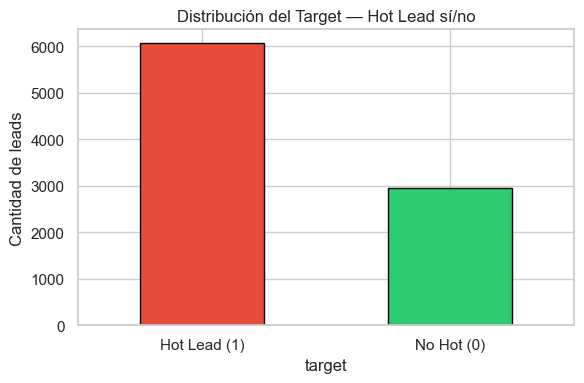

In [8]:
df["target"] = (df["cualificacion"] == "Contacto interesado").astype(int)

hot_leads = df["target"].sum()
no_hot = len(df) - hot_leads

print("=== DISTRIBUCIÓN DEL TARGET ===\n")
print(f"  1 (Hot Lead):  {hot_leads:,} ({hot_leads/len(df)*100:.1f}%)")
print(f"  0 (No Hot):    {no_hot:,} ({no_hot/len(df)*100:.1f}%)")
print(f"  Total:         {len(df):,}")

plt.figure(figsize=(6, 4))
df["target"].value_counts().plot(kind="bar", color=["#e74c3c", "#2ecc71"], edgecolor="black")
plt.xticks([0, 1], ["Hot Lead (1)", "No Hot (0)"], rotation=0)
plt.title("Distribución del Target — Hot Lead sí/no")
plt.ylabel("Cantidad de leads")
plt.tight_layout()
plt.show()

## 7. Eliminar columnas con data leakage y sin valor predictivo

**¿Qué es data leakage (fuga de datos)?**  
Es cuando el modelo tiene acceso a información que **no existiría** al momento de hacer la predicción real. Es como hacer un examen con las respuestas: el modelo saca buena nota en el entrenamiento pero falla en la vida real.

**Ejemplo concreto:** La columna `numero_matricula` solo se completa cuando un lead es HOT. Si el modelo ve que tiene valor → siempre predice 1. Eso es trampa.

Eliminamos 3 tipos de columnas:
1. **Data leakage** (11 cols): datos que se generan DESPUÉS del ingreso del lead
2. **Sin valor predictivo** (3 cols): ID, tipo constante, cualificación original
3. La columna `cualificacion` original (ya la reemplazamos por `target`)

In [9]:
COLS_LEAKAGE = [
    "sub_cualificacion",        # Consecuencia directa del target
    "otra_informacion",         # Resultado del proceso de cualificación
    "comentario",               # Notas de seguimiento post-contacto
    "descripcion",              # Detalle del chatbot/proceso, posterior
    "fecha_reasignacion",       # Timestamp posterior a la cualificación
    "primera_fecha_accion",     # Timestamp de acción sobre el lead
    "usuario_reasignacion",     # Usuario que reasignó, dato posterior
    "numero_matricula",         # Solo se llena en leads HOT → leakage directa
    "propietario_candidato",    # Se asigna/modifica durante el proceso
    "ultimo_alias",             # Usuario interno que modificó durante proceso
    "tiempo_primer_contacto",   # Ocurre DESPUÉS del ingreso del lead
]

COLS_SIN_VALOR = [
    "lead_id",                  # Identificador único, no predictivo
    "tipo_interes",             # Constante: siempre "Vehículo Nuevo"
    "cualificacion",            # Reemplazada por la columna 'target'
]

cols_a_eliminar = COLS_LEAKAGE + COLS_SIN_VALOR
cols_antes = len(df.columns)

df = df.drop(columns=cols_a_eliminar)

print(f"Columnas antes:     {cols_antes}")
print(f"Columnas eliminadas: {len(cols_a_eliminar)}")
print(f"Columnas después:   {len(df.columns)}")
print(f"\nColumnas restantes ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Columnas antes:     28
Columnas eliminadas: 14
Columnas después:   14

Columnas restantes (14):
   1. anio_creacion
   2. mes_creacion
   3. dia_creacion
   4. hora_creacion
   5. dia_semana_creacion
   6. nombre_formulario
   7. campana
   8. plataforma
   9. origen_creacion
  10. subtipo_interes
  11. vehiculo_interes
  12. concesion
  13. origen
  14. target


## 8. Manejo de valores nulos

La mayoría de modelos de scikit-learn **no aceptan valores NaN** (nulos). Hay que decidir qué hacer con ellos.

**Estrategias comunes:**
- **Imputar con un valor de negocio**: Si sabemos qué significa el nulo (ej: campaña vacía = lead orgánico → "sin_campana")
- **Imputar con la moda**: Para categóricas, se usa el valor más frecuente
- **Imputar con mediana**: Para numéricas, la mediana es más robusta que la media ante outliers
- **Eliminar filas**: Solo si son muy pocas y no hay patrón

En nuestro caso, cada nulo tiene una explicación de negocio.

In [10]:
print("=== NULOS EN COLUMNAS RESTANTES (antes de imputar) ===\n")
nulos_restantes = df.isnull().sum()
for col in df.columns:
    n = nulos_restantes[col]
    if n > 0:
        print(f"  {col:30s} → {n:,} nulos ({n/len(df)*100:.1f}%)")

=== NULOS EN COLUMNAS RESTANTES (antes de imputar) ===



  campana                        → 4,588 nulos (50.9%)
  vehiculo_interes               → 20 nulos (0.2%)
  concesion                      → 5 nulos (0.1%)
  origen                         → 887 nulos (9.8%)


In [11]:
# Campaña vacía = lead que entró por canal orgánico, sin campaña paga
df["campana"] = df["campana"].fillna("sin_campana")

# Origen vacío = canal desconocido
df["origen"] = df["origen"].fillna("desconocido")

# Vehículo de interés vacío = no seleccionó modelo (muy pocos casos)
vehiculo_moda = df["vehiculo_interes"].mode()[0]
df["vehiculo_interes"] = df["vehiculo_interes"].fillna(vehiculo_moda)

# Concesión vacía = el lead no eligió concesionario en el formulario
df["concesion"] = df["concesion"].fillna("sin_concesion")

print("Imputación de nulos completada:")
print(f"  campana         → 'sin_campana'")
print(f"  origen          → 'desconocido'")
print(f"  vehiculo_interes → '{vehiculo_moda}' (moda)")
print(f"  concesion       → 'sin_concesion'")
print(f"\nNulos restantes: {df.isnull().sum().sum()}")

Imputación de nulos completada:
  campana         → 'sin_campana'
  origen          → 'desconocido'
  vehiculo_interes → 'KWID' (moda)
  concesion       → 'sin_concesion'

Nulos restantes: 0


## 9. Verificar duplicados y validar datos

Verificamos que no haya filas duplicadas y que los datos sean consistentes. Usamos **`assert`** para validaciones automáticas: si algo falla, el notebook se detiene y nos avisa.

In [12]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print(f"  → Eliminadas. Filas restantes: {len(df):,}")

# Validaciones automáticas
assert df.isnull().sum().sum() == 0, "ERROR: Quedan valores nulos"
assert set(df["target"].unique()) == {0, 1}, "ERROR: Target no es binario"
assert len(df) > 0, "ERROR: DataFrame vacío"

print("\nValidaciones pasadas:")
print("  Sin valores nulos")
print("  Target es binario (0 y 1)")
print(f"  DataFrame tiene {len(df):,} filas")

Filas duplicadas encontradas: 588
  → Eliminadas. Filas restantes: 8,422

Validaciones pasadas:
  Sin valores nulos
  Target es binario (0 y 1)
  DataFrame tiene 8,422 filas


## 10. Reporte de transformación y exportar dataset limpio

Generamos un resumen comparativo entre el dataset **raw** (original) y el dataset **limpio** (procesado), para que el profesor pueda ver claramente qué se hizo y por qué.

Finalmente, exportamos el dataset limpio a `data/processed/leads_cleaned.csv` en **UTF-8** (encoding universal).

In [13]:
print("=" * 65)
print("     REPORTE DE TRANSFORMACIÓN — DATA ENGINEERING")
print("=" * 65)

print(f"\n{'Métrica':<40} {'Raw':>10} {'Limpio':>10}")
print("-" * 65)
print(f"{'Filas':<40} {len(df_raw):>10,} {len(df):>10,}")
print(f"{'Columnas':<40} {len(df_raw.columns):>10} {len(df.columns):>10}")
print(f"{'Valores nulos totales':<40} {df_raw.isnull().sum().sum():>10,} {df.isnull().sum().sum():>10}")
print(f"{'Filas eliminadas (bot)':<40} {len(df_raw) - len(df):>10,} {'—':>10}")
print(f"{'Columnas eliminadas':<40} {len(df_raw.columns) - len(df.columns):>10} {'—':>10}")

print(f"\n{'Target':<40} {'Cantidad':>10} {'%':>10}")
print("-" * 65)
hot = df["target"].sum()
no_hot = len(df) - hot
print(f"{'1 — Hot Lead (Contacto interesado)':<40} {hot:>10,} {hot/len(df)*100:>9.1f}%")
print(f"{'0 — No Hot (Rechazo)':<40} {no_hot:>10,} {no_hot/len(df)*100:>9.1f}%")

print(f"\n{'Columnas finales:'}")
for i, col in enumerate(df.columns, 1):
    dtype = "numérica" if df[col].dtype in ["int64", "float64"] else "categórica"
    print(f"  {i:2d}. {col:30s} ({dtype})")

print("\n" + "=" * 65)

     REPORTE DE TRANSFORMACIÓN — DATA ENGINEERING

Métrica                                         Raw     Limpio
-----------------------------------------------------------------
Filas                                        13,516      8,422
Columnas                                         27         14
Valores nulos totales                        83,107          0
Filas eliminadas (bot)                        5,094          —
Columnas eliminadas                              13          —

Target                                     Cantidad          %
-----------------------------------------------------------------
1 — Hot Lead (Contacto interesado)            5,782      68.7%
0 — No Hot (Rechazo)                          2,640      31.3%

Columnas finales:
   1. anio_creacion                  (numérica)
   2. mes_creacion                   (numérica)
   3. dia_creacion                   (numérica)
   4. hora_creacion                  (numérica)
   5. dia_semana_creacion            (

In [14]:
CLEAN_PATH = "../data/processed/leads_cleaned.csv"

df.to_csv(CLEAN_PATH, index=False, encoding="utf-8")

print(f"Dataset limpio exportado a: {CLEAN_PATH}")
print(f"  Encoding: UTF-8")
print(f"  Filas: {len(df):,}")
print(f"  Columnas: {len(df.columns)}")
print(f"\nData Engineering completado.")

Dataset limpio exportado a: ../data/processed/leads_cleaned.csv
  Encoding: UTF-8
  Filas: 8,422
  Columnas: 14

Data Engineering completado.
